# Statistical Tests for Time Series Analysis on NIFTY50 5 min OHLC Data 📈

## 1. Augmented Dickey-Fuller (ADF) Test 🎯

### Purpose
> Tests for stationarity in time series data (Critical for prediction)

### Why Important
* **Model Prerequisites**
  - Essential for ARIMA modeling
  - Foundation for reliable predictions

### Interpretation
| Result | Meaning | Action |
|--------|---------|--------|
| p < 0.05 | Stationary | Ready for modeling |
| p > 0.05 | Non-stationary | Need differencing |

### Impact on Models
* **ARIMA**: Determines 'd' parameter directly
* **Transformers**: Guides data preprocessing strategy

---

## 2. ACF (Autocorrelation Function) 📊

### Purpose
> Reveals relationship between current and past values

### Key Insights
* **Pattern Detection**
  - Series memory depth
  - Seasonal patterns
  - Trend strength

### Pattern Interpretation
* **Slow Decay**: Strong trend present
* **Periodic Spikes**: Seasonal patterns exist
* **Quick Decay**: Weak autocorrelation

### Model Implications
* **ARIMA**: Helps set 'q' (MA) parameter
* **Transformers**: Guides sequence length choice

---

## 3. PACF (Partial Autocorrelation Function) 🔍

### Purpose
> Shows direct relationships between time points

### Key Benefits
* **Direct Dependencies**
  - Pure lag relationships
  - Optimal lookback period
  - AR order identification

### Pattern Reading
* **Significant Spikes**: Direct relationships
* **Cut-off Point**: Suggests AR order
* **Decay Pattern**: Complexity indicator

### Model Applications
* **ARIMA**: Sets 'p' (AR) parameter
* **Transformers**: Guides attention window

---

## 4. Ljung-Box Test ⚖️

### Purpose
> Validates residual randomness

### Importance
* **Model Validation**
  - Tests assumptions
  - Checks pattern capture
  - Quality assurance

### Results Guide
| p-value | Interpretation | Next Steps |
|---------|----------------|------------|
| > 0.05 | Good fit | Proceed with model |
| < 0.05 | Missing patterns | Model refinement needed |

---

## Trading Strategy Implementation 💹

### Data Properties Analysis
* **Pattern Understanding**
  - Price movement characteristics
  - Key time intervals
  - Preprocessing requirements

### Model Selection Framework
| Pattern | Suggested Model | Why |
|---------|----------------|-----|
| Strong seasonality | ARIMA | Good for regular patterns |
| Complex patterns | Transformers | Better with non-linear relationships |
| High randomness | Feature enrichment | Need more predictive signals |

### Parameter Optimization
1. **ARIMA Parameters**
   - p: From PACF analysis
   - d: From ADF test
   - q: From ACF analysis

2. **Transformer Settings**
   - Sequence length
   - Attention window
   - Feature engineering scope

---


In [1]:
# !pip install mlflow
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import seaborn as sns
import gc
# import mlflow

In [2]:
# Input File - Data 2014 to 2024 - 1min ohlc 
# 6 Parts - Last 6month 5 min ohlc, last to last 6 month 5 min ohlc, in similar fashion 1 year and 2 year.
## created df1- df6 serieses

In [4]:
# Data Extraction
def resample_and_get_periods(csv_path, interval='5T'):
   """
   Load data, resample to 5 min OHLC, perform quality checks, and split into periods
   
   Parameters:
   - csv_path: path to CSV file
   - interval: resampling interval (default '5T' for 5 minutes)
   
   Returns: Dictionary of quality-checked, resampled dataframes for different periods
   """
   # Load data
   def load_and_clean(csv_path):
       df = pd.read_csv(csv_path)
       df['date'] = pd.to_datetime(df['date'])
       return df.set_index('date').sort_index()
   
   # Quality checks
   def quality_checks(df, period_name):
       issues = []
       
       # Check for missing values
       missing = df.isnull().sum()
       if missing.any():
           issues.append(f"Missing values found: {missing[missing > 0]}")
           
       # Check for duplicates
       duplicates = df.index.duplicated().sum()
       if duplicates:
           issues.append(f"Found {duplicates} duplicate timestamps")
           
       # Check for price anomalies
       price_std = df['close'].std()
       price_mean = df['close'].mean()
       outliers = df[abs(df['close'] - price_mean) > 3 * price_std]
       if not outliers.empty:
           issues.append(f"Found {len(outliers)} potential price outliers")
           
       # Check for gaps in time series
       time_diff = df.index.to_series().diff()
       gaps = time_diff[time_diff > pd.Timedelta(minutes=6)]  # More than 6 min gap
       if not gaps.empty:
           issues.append(f"Found {len(gaps)} time gaps > 6 minutes")
           
       # Print issues for this period
       if issues:
           print(f"\nQuality issues in {period_name}:")
           for issue in issues:
               print(f"- {issue}")
               
       return len(issues) == 0
   
   # Resample to 5 min OHLC
   def resample_ohlc(df, interval):
       resampled = df.resample(interval).agg({
           'open': 'first',
           'high': 'max',
           'low': 'min',
           'close': 'last',
           'volume': 'sum'
       })
       return resampled.dropna()  # Remove any incomplete periods
   
   print("Loading and preprocessing data...")
   df = load_and_clean(csv_path)
   
   # Resample full dataset
   df_resampled = resample_ohlc(df, interval)
   
   # Get end date
   end_date = df_resampled.index.max()
   
   # Define periods and create slices
   periods = {
       'last_6m': (end_date - pd.DateOffset(months=6), end_date),
       'last_to_last_6m': (end_date - pd.DateOffset(months=12), 
                          end_date - pd.DateOffset(months=6)),
       'last_1y': (end_date - pd.DateOffset(years=1), end_date),
       'last_to_last_1y': (end_date - pd.DateOffset(years=2), 
                          end_date - pd.DateOffset(years=1)),
       'last_2y': (end_date - pd.DateOffset(years=2), end_date),
       'last_to_last_2y': (end_date - pd.DateOffset(years=4), 
                          end_date - pd.DateOffset(years=2))
   }
   
   datasets = {}
   print("\nCreating and validating period datasets...")
   
   for name, (start, end) in periods.items():
       # Slice data
       period_data = df_resampled[start:end].copy()
       
       # Perform quality checks
       is_clean = quality_checks(period_data, name)
       
       # Store data and metadata
       datasets[name] = {
           'data': period_data,
           'metadata': {
               'start_date': period_data.index.min(),
               'end_date': period_data.index.max(),
               'records': len(period_data),
               'trading_days': len(set(period_data.index.date)),
               'quality_passed': is_clean
           }
       }
   
   # Print summary
   print("\nPeriod Summaries:")
   print("="*70)
   for name, dataset in datasets.items():
       meta = dataset['metadata']
       print(f"\n{name}:")
       print(f"Date Range: {meta['start_date']} to {meta['end_date']}")
       print(f"Records: {meta['records']}, Trading Days: {meta['trading_days']}")
       print(f"Quality Check: {'✓' if meta['quality_passed'] else '✗'}")
   
   return datasets

# Usage
csv_path = 'nifty50_1min_2015_to_2024.csv'
datasets = resample_and_get_periods(csv_path)

# # Access data for a period
df1 = datasets['last_6m']['data']
# # last_6m_metadata = datasets['last_6m']['metadata']
# df2 = datasets['last_to_last_6m']['data']
# df3 = datasets['last_1y']['data']
# df4 = datasets['last_to_last_1y']['data']
# df5 = datasets['last_2y']['data']
# df6 = datasets['last_to_last_2y']['data']
# df1["Return"] = df1["close"].pct_change()
# df1 = df1["Return"].dropna()
# df2["Return"] = df2["close"].pct_change()
# df2 = df2["Return"].dropna()
# df3["Return"] = df3["close"].pct_change()
# df3 = df3["Return"].dropna()
# df4["Return"] = df4["close"].pct_change()
# df4 = df4["Return"].dropna()
# df5["Return"] = df5["close"].pct_change()
# df5 = df5["Return"].dropna()
# df6["Return"] = df6["close"].pct_change()
# df6 = df6["Return"].dropna()

# print(df1)

# df_0 = pd.read_csv(csv_path)
# df_0['date'] = pd.to_datetime(df_0['date'])
# df_0 = df_0.set_index('date').sort_index()
# df_0 = df_0.resample('5T').agg({
#     'open': 'first',
#     'high': 'max',
#     'low': 'min',
#     'close': 'last',
#     'volume': 'sum'
# }).fillna(method='ffill')
# df_0['Return'] = df_0['close'].pct_change()
# df0 = df_0["Return"].dropna()

Loading and preprocessing data...

Creating and validating period datasets...

Quality issues in last_6m:
- Found 124 time gaps > 6 minutes

Quality issues in last_to_last_6m:
- Found 126 time gaps > 6 minutes

Quality issues in last_1y:
- Found 250 time gaps > 6 minutes

Quality issues in last_to_last_1y:
- Found 247 time gaps > 6 minutes

Quality issues in last_2y:
- Found 497 time gaps > 6 minutes

Quality issues in last_to_last_2y:
- Found 496 time gaps > 6 minutes

Period Summaries:

last_6m:
Date Range: 2024-02-28 15:25:00+05:30 to 2024-08-28 15:25:00+05:30
Records: 9043, Trading Days: 123
Quality Check: ✗

last_to_last_6m:
Date Range: 2023-08-28 15:25:00+05:30 to 2024-02-28 15:25:00+05:30
Records: 9388, Trading Days: 127
Quality Check: ✗

last_1y:
Date Range: 2023-08-28 15:25:00+05:30 to 2024-08-28 15:25:00+05:30
Records: 18430, Trading Days: 249
Quality Check: ✗

last_to_last_1y:
Date Range: 2022-08-29 09:15:00+05:30 to 2023-08-28 15:25:00+05:30
Records: 18537, Trading Days: 24

In [7]:
from_last_complete_half_data = df0[400000:]
gc.collect()

0

In [4]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_stationarity(returns_series, title="Returns Analysis", sample_size=10000):
    """
    Memory-efficient stationarity analysis using sampling
    
    Parameters:
    returns_series: Series of returns data
    title: Title for plots
    sample_size: Number of points to sample for visualization
    """
    
    # Efficient sampling for large datasets
    if len(returns_series) > sample_size:
        plot_data = returns_series.sample(n=sample_size, random_state=42)
    else:
        plot_data = returns_series
        
    # Run ADF Test on chunks if data is too large
    if len(returns_series) > 100000:
        chunk_size = 100000
        chunks = [returns_series[i:i+chunk_size] for i in range(0, len(returns_series), chunk_size)]
        adf_results = []
        for chunk in chunks[:3]:  # Test first 3 chunks
            adf_results.append(adfuller(chunk))
        # Use the median of test results
        adf_result = (
            np.median([r[0] for r in adf_results]),
            np.median([r[1] for r in adf_results]),
            np.median([r[2] for r in adf_results]),
            None,
            {k: np.median([r[4][k] for r in adf_results]) for k in adf_results[0][4].keys()}
        )
    else:
        adf_result = adfuller(returns_series)
    
    # Memory-efficient plotting
    plt.style.use('seaborn')
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: Returns Time Series (sampled)
    axes[0].plot(plot_data.index, plot_data.values, linewidth=0.5)
    axes[0].set_title(f"{title} - Time Series Plot (Sampled)")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Returns")
    
    # Plot 2: Returns Distribution (sampled)
    axes[1].hist(plot_data.values, bins=50, density=True, alpha=0.7)
    axes[1].set_title("Returns Distribution (Sampled)")
    axes[1].set_xlabel("Return Value")
    
    plt.tight_layout()
    
    # Efficient statistics calculation
    results = {
        'test_statistic': adf_result[0],
        'p_value': adf_result[1],
        'critical_values': adf_result[4],
        'is_stationary': adf_result[1] < 0.05,
        'statistics': {
            'mean': float(returns_series.mean()),
            'std': float(returns_series.std()),
            'skew': float(returns_series.skew()),
            'kurtosis': float(returns_series.kurtosis())
        }
    }
    
    # Print minimal results
    print(f"\nADF Test: {'Stationary' if results['is_stationary'] else 'Non-stationary'}")
    print(f"P-value: {results['p_value']:.4f}")
    
    return results, fig

def document_stationarity_analysis(returns_series):
    """
    Memory-efficient documentation of stationarity analysis
    """
    try:
        results, fig = analyze_stationarity(df0)
        
        markdown_doc = f"""
# Stationarity Analysis Summary

## Key Findings
- **Stationarity**: {'Stationary' if results['is_stationary'] else 'Non-stationary'}
- **P-value**: {results['p_value']:.4f}

## Statistical Properties
- Mean: {results['statistics']['mean']:.6f}
- Std Dev: {results['statistics']['std']:.6f}
- Skewness: {results['statistics']['skew']:.6f}
- Kurtosis: {results['statistics']['kurtosis']:.6f}

## Modeling Implications
1. {'Use raw returns' if results['is_stationary'] else 'Consider differencing'}
2. {'Direct modeling possible' if results['is_stationary'] else 'Transform data first'}
"""
        plt.close(fig)  # Clean up memory
        return results
        
    except Exception as e:
        return f"Analysis failed: {str(e)}"


doc = document_stationarity_analysis(df0)
print(doc)

/tmp/ipykernel_1/3531678886.py:42: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')



ADF Test: Stationary
P-value: 0.0000
{'test_statistic': -36.25057614269722, 'p_value': 0.0, 'critical_values': {'1%': -3.4304154398333235, '5%': -2.861568923380865, '10%': -2.5667853949035773}, 'is_stationary': True, 'statistics': {'mean': 1.2091071912458163e-06, 'std': 0.00048810226000622263, 'skew': -11.09759588179488, 'kurtosis': 3054.7869383028105}}


In [11]:
results

NameError: name 'results' is not defined

In [5]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_stationarity(returns_series, title="Returns Analysis"):
   """
   Comprehensive stationarity analysis using ADF test
   
   Parameters:
   returns_series: Series of returns data
   title: Title for plots
   
   Returns:
   Dictionary containing test results and interpretation
   """
   
   # Run ADF Test
   adf_result = adfuller(returns_series)
   
   # Create visualization
   fig, axes = plt.subplots(2, 1, figsize=(15, 10))
   
   # Plot 1: Returns Time Series
   axes[0].plot(returns_series)
   axes[0].set_title(f"{title} - Time Series Plot")
   axes[0].set_xlabel("Time")
   axes[0].set_ylabel("Returns")
   
   # Plot 2: Returns Distribution
   sns.histplot(returns_series, kde=True, ax=axes[1])
   axes[1].set_title("Returns Distribution")
   axes[1].set_xlabel("Return Value")
   
   # Compile results
   results = {
       'test_statistic': adf_result[0],
       'p_value': adf_result[1],
       'critical_values': adf_result[4],
       'is_stationary': adf_result[1] < 0.05,
   }
   
   # Print detailed interpretation
   print("\n=== Augmented Dickey-Fuller Test Results ===")
   print(f"Test Statistic: {results['test_statistic']:.4f}")
   print(f"P-value: {results['p_value']:.4f}")
   print("\nCritical Values:")
   for key, value in results['critical_values'].items():
       print(f"\t{key}: {value:.4f}")
   
   print("\nInterpretation:")
   print("-" * 50)
   if results['is_stationary']:
       print("✓ Series is STATIONARY")
       print("• Suitable for direct modeling")
       print("• ARIMA: No differencing needed (d=0)")
       print("• Good for prediction tasks")
   else:
       print("✗ Series is NON-STATIONARY")
       print("• Needs differencing before modeling")
       print("• ARIMA: Use d>0")
       print("• Consider transforming data")
   
   # Additional statistics
   results['statistics'] = {
       'mean': returns_series.mean(),
       'std': returns_series.std(),
       'skew': returns_series.skew(),
       'kurtosis': returns_series.kurtosis()
   }
   
   print("\nBasic Statistics:")
   print(f"Mean: {results['statistics']['mean']:.6f}")
   print(f"Std Dev: {results['statistics']['std']:.6f}")
   print(f"Skewness: {results['statistics']['skew']:.6f}")
   print(f"Kurtosis: {results['statistics']['kurtosis']:.6f}")
   
   return results, fig

# Example usage
def document_stationarity_analysis(df1):
   """
   Document stationarity analysis results in markdown format
   """
   results, fig = analyze_stationarity(from_last_complete_half_data,title="Returns Analysis")
   
   markdown_doc = f"""
# Stationarity Analysis Report 📊

## Test Results
- **ADF Test Statistic**: {results['test_statistic']:.4f}
- **P-value**: {results['p_value']:.4f}
- **Is Stationary**: {'Yes' if results['is_stationary'] else 'No'}

## Critical Values
"""
   for key, value in results['critical_values'].items():
       markdown_doc += f"- {key}: {value:.4f}\n"
   
   markdown_doc += f"""
## Statistical Properties
- Mean: {results['statistics']['mean']:.6f}
- Standard Deviation: {results['statistics']['std']:.6f}
- Skewness: {results['statistics']['skew']:.6f}
- Kurtosis: {results['statistics']['kurtosis']:.6f}

## Implications for Modeling

### ARIMA
- {'Use original series (d=0)' if results['is_stationary'] else 'Need differencing (d>0)'}
- {'Ready for AR and MA components' if results['is_stationary'] else 'Transform data first'}

### Transformers
- {'Use raw returns' if results['is_stationary'] else 'Consider preprocessing'}
- Feature engineering implications: {
   'Direct feature creation possible' if results['is_stationary'] 
   else 'Need to handle non-stationarity in features'
}

## Recommendations
1. {
   'Proceed with modeling using raw returns' if results['is_stationary'] 
   else 'Apply differencing or transformation'
}
2. {
   'Focus on model selection' if results['is_stationary'] 
   else 'Validate stationarity after transformation'
}
3. Consider return distribution characteristics for model assumptions
"""
   
   return markdown_doc

# #Usage
# returns_df = your_processed_dataframe
# doc = document_stationarity_analysis(returns_df)
# print(doc)  # Or save to markdown file

In [ ]:
analyze_stationarity(from_last_complete_half_data,title="Returns Analysis")

In [6]:
# df2 ADFuller test analysis

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_stationarity(returns_series, title="Returns Analysis"):
   """
   Comprehensive stationarity analysis using ADF test
   
   Parameters:
   returns_series: Series of returns data
   title: Title for plots
   
   Returns:
   Dictionary containing test results and interpretation
   """
   
   # Run ADF Test
   adf_result = adfuller(returns_series)
   
   # Create visualization
   fig, axes = plt.subplots(2, 1, figsize=(15, 10))
   
   # Plot 1: Returns Time Series
   axes[0].plot(returns_series)
   axes[0].set_title(f"{title} - Time Series Plot")
   axes[0].set_xlabel("Time")
   axes[0].set_ylabel("Returns")
   
   # Plot 2: Returns Distribution
   sns.histplot(returns_series, kde=True, ax=axes[1])
   axes[1].set_title("Returns Distribution")
   axes[1].set_xlabel("Return Value")
   
   # Compile results
   results = {
       'test_statistic': adf_result[0],
       'p_value': adf_result[1],
       'critical_values': adf_result[4],
       'is_stationary': adf_result[1] < 0.05,
   }
   
   # Print detailed interpretation
   print("\n=== Augmented Dickey-Fuller Test Results ===")
   print(f"Test Statistic: {results['test_statistic']:.4f}")
   print(f"P-value: {results['p_value']:.4f}")
   print("\nCritical Values:")
   for key, value in results['critical_values'].items():
       print(f"\t{key}: {value:.4f}")
   
   print("\nInterpretation:")
   print("-" * 50)
   if results['is_stationary']:
       print("✓ Series is STATIONARY")
       print("• Suitable for direct modeling")
       print("• ARIMA: No differencing needed (d=0)")
       print("• Good for prediction tasks")
   else:
       print("✗ Series is NON-STATIONARY")
       print("• Needs differencing before modeling")
       print("• ARIMA: Use d>0")
       print("• Consider transforming data")
   
   # Additional statistics
   results['statistics'] = {
       'mean': returns_series.mean(),
       'std': returns_series.std(),
       'skew': returns_series.skew(),
       'kurtosis': returns_series.kurtosis()
   }
   
   print("\nBasic Statistics:")
   print(f"Mean: {results['statistics']['mean']:.6f}")
   print(f"Std Dev: {results['statistics']['std']:.6f}")
   print(f"Skewness: {results['statistics']['skew']:.6f}")
   print(f"Kurtosis: {results['statistics']['kurtosis']:.6f}")
   
   return results, fig

# Example usage
def document_stationarity_analysis(df2):
   """
   Document stationarity analysis results in markdown format
   """
   results, fig = analyze_stationarity(df2,title="Returns Analysis")
   
   markdown_doc = f"""
# Stationarity Analysis Report 📊

## Test Results
- **ADF Test Statistic**: {results['test_statistic']:.4f}
- **P-value**: {results['p_value']:.4f}
- **Is Stationary**: {'Yes' if results['is_stationary'] else 'No'}

## Critical Values
"""
   for key, value in results['critical_values'].items():
       markdown_doc += f"- {key}: {value:.4f}\n"
   
   markdown_doc += f"""
## Statistical Properties
- Mean: {results['statistics']['mean']:.6f}
- Standard Deviation: {results['statistics']['std']:.6f}
- Skewness: {results['statistics']['skew']:.6f}
- Kurtosis: {results['statistics']['kurtosis']:.6f}

## Implications for Modeling

### ARIMA
- {'Use original series (d=0)' if results['is_stationary'] else 'Need differencing (d>0)'}
- {'Ready for AR and MA components' if results['is_stationary'] else 'Transform data first'}

### Transformers
- {'Use raw returns' if results['is_stationary'] else 'Consider preprocessing'}
- Feature engineering implications: {
   'Direct feature creation possible' if results['is_stationary'] 
   else 'Need to handle non-stationarity in features'
}

## Recommendations
1. {
   'Proceed with modeling using raw returns' if results['is_stationary'] 
   else 'Apply differencing or transformation'
}
2. {
   'Focus on model selection' if results['is_stationary'] 
   else 'Validate stationarity after transformation'
}
3. Consider return distribution characteristics for model assumptions
"""
   
   return markdown_doc

# #Usage
# returns_df = your_processed_dataframe
# doc = document_stationarity_analysis(returns_df)
# print(doc)  # Or save to markdown file


=== Augmented Dickey-Fuller Test Results ===
Test Statistic: -47.1609
P-value: 0.0000

Critical Values:
	1%: -3.4310
	5%: -2.8618
	10%: -2.5669

Interpretation:
--------------------------------------------------
✓ Series is STATIONARY
• Suitable for direct modeling
• ARIMA: No differencing needed (d=0)
• Good for prediction tasks

Basic Statistics:
Mean: 0.000014
Std Dev: 0.000729
Skewness: 1.459348
Kurtosis: 36.856690


({'test_statistic': -47.160871930636766,
  'p_value': 0.0,
  'critical_values': {'1%': -3.4310471213772034,
   '5%': -2.8618480839493126,
   '10%': -2.5669339879965047},
  'is_stationary': True,
  'statistics': {'mean': 1.3841844604194399e-05,
   'std': 0.0007287216270319258,
   'skew': 1.4593479788372687,
   'kurtosis': 36.856690441872615}},
 <Figure size 1500x1000 with 2 Axes>)

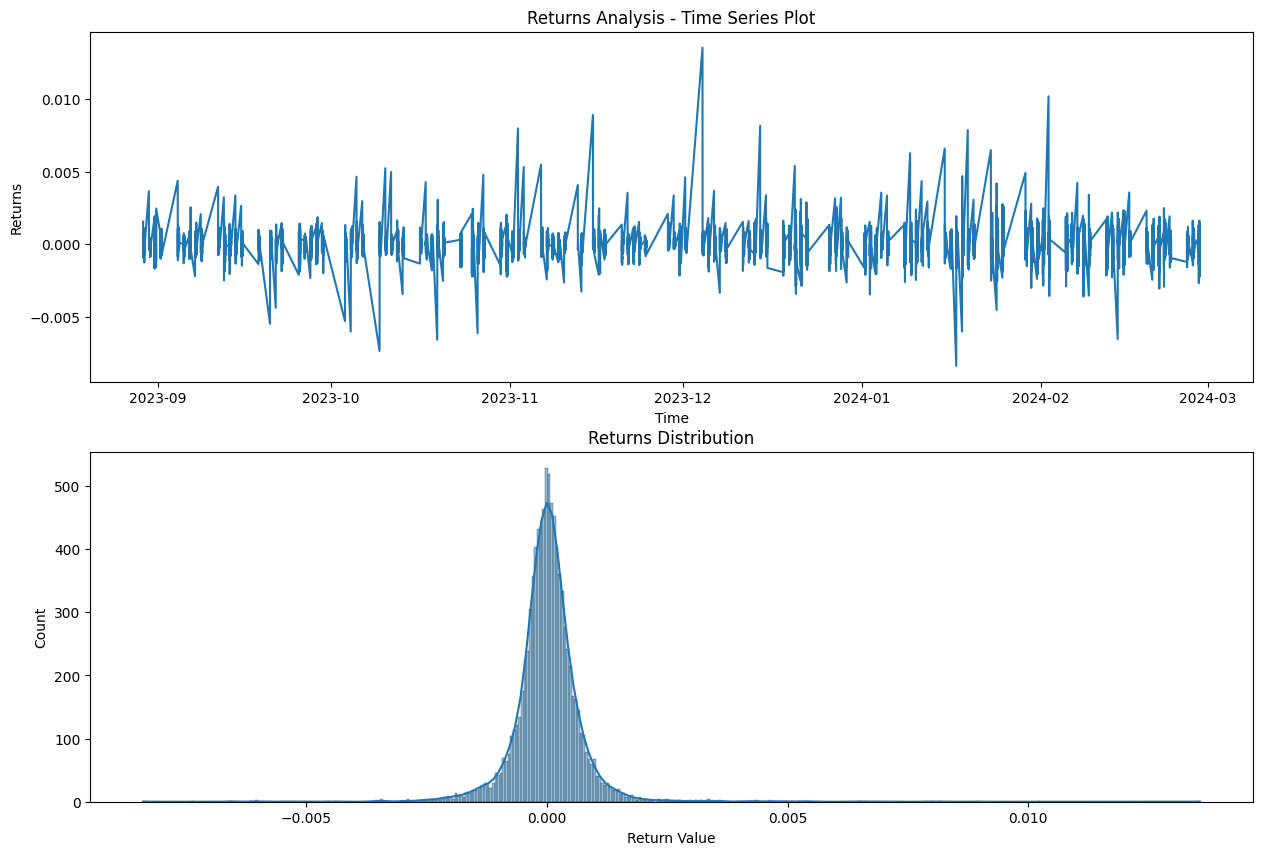

In [7]:
analyze_stationarity(df2,title="Returns Analysis")

In [8]:
# df3 ADFuller test analysis

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_stationarity(returns_series, title="Returns Analysis"):
   """
   Comprehensive stationarity analysis using ADF test
   
   Parameters:
   returns_series: Series of returns data
   title: Title for plots
   
   Returns:
   Dictionary containing test results and interpretation
   """
   
   # Run ADF Test
   adf_result = adfuller(returns_series)
   
   # Create visualization
   fig, axes = plt.subplots(2, 1, figsize=(15, 10))
   
   # Plot 1: Returns Time Series
   axes[0].plot(returns_series)
   axes[0].set_title(f"{title} - Time Series Plot")
   axes[0].set_xlabel("Time")
   axes[0].set_ylabel("Returns")
   
   # Plot 2: Returns Distribution
   sns.histplot(returns_series, kde=True, ax=axes[1])
   axes[1].set_title("Returns Distribution")
   axes[1].set_xlabel("Return Value")
   
   # Compile results
   results = {
       'test_statistic': adf_result[0],
       'p_value': adf_result[1],
       'critical_values': adf_result[4],
       'is_stationary': adf_result[1] < 0.05,
   }
   
   # Print detailed interpretation
   print("\n=== Augmented Dickey-Fuller Test Results ===")
   print(f"Test Statistic: {results['test_statistic']:.4f}")
   print(f"P-value: {results['p_value']:.4f}")
   print("\nCritical Values:")
   for key, value in results['critical_values'].items():
       print(f"\t{key}: {value:.4f}")
   
   print("\nInterpretation:")
   print("-" * 50)
   if results['is_stationary']:
       print("✓ Series is STATIONARY")
       print("• Suitable for direct modeling")
       print("• ARIMA: No differencing needed (d=0)")
       print("• Good for prediction tasks")
   else:
       print("✗ Series is NON-STATIONARY")
       print("• Needs differencing before modeling")
       print("• ARIMA: Use d>0")
       print("• Consider transforming data")
   
   # Additional statistics
   results['statistics'] = {
       'mean': returns_series.mean(),
       'std': returns_series.std(),
       'skew': returns_series.skew(),
       'kurtosis': returns_series.kurtosis()
   }
   
   print("\nBasic Statistics:")
   print(f"Mean: {results['statistics']['mean']:.6f}")
   print(f"Std Dev: {results['statistics']['std']:.6f}")
   print(f"Skewness: {results['statistics']['skew']:.6f}")
   print(f"Kurtosis: {results['statistics']['kurtosis']:.6f}")
   
   return results, fig

# Example usage
def document_stationarity_analysis(df3):
   """
   Document stationarity analysis results in markdown format
   """
   results, fig = analyze_stationarity(df3,title="Returns Analysis")
   
   markdown_doc = f"""
# Stationarity Analysis Report 📊

## Test Results
- **ADF Test Statistic**: {results['test_statistic']:.4f}
- **P-value**: {results['p_value']:.4f}
- **Is Stationary**: {'Yes' if results['is_stationary'] else 'No'}

## Critical Values
"""
   for key, value in results['critical_values'].items():
       markdown_doc += f"- {key}: {value:.4f}\n"
   
   markdown_doc += f"""
## Statistical Properties
- Mean: {results['statistics']['mean']:.6f}
- Standard Deviation: {results['statistics']['std']:.6f}
- Skewness: {results['statistics']['skew']:.6f}
- Kurtosis: {results['statistics']['kurtosis']:.6f}

## Implications for Modeling

### ARIMA
- {'Use original series (d=0)' if results['is_stationary'] else 'Need differencing (d>0)'}
- {'Ready for AR and MA components' if results['is_stationary'] else 'Transform data first'}

### Transformers
- {'Use raw returns' if results['is_stationary'] else 'Consider preprocessing'}
- Feature engineering implications: {
   'Direct feature creation possible' if results['is_stationary'] 
   else 'Need to handle non-stationarity in features'
}

## Recommendations
1. {
   'Proceed with modeling using raw returns' if results['is_stationary'] 
   else 'Apply differencing or transformation'
}
2. {
   'Focus on model selection' if results['is_stationary'] 
   else 'Validate stationarity after transformation'
}
3. Consider return distribution characteristics for model assumptions
"""
   
   return markdown_doc

# #Usage
# returns_df = your_processed_dataframe
# doc = document_stationarity_analysis(returns_df)
# print(doc)  # Or save to markdown file


=== Augmented Dickey-Fuller Test Results ===
Test Statistic: -18.6247
P-value: 0.0000

Critical Values:
	1%: -3.4307
	5%: -2.8617
	10%: -2.5669

Interpretation:
--------------------------------------------------
✓ Series is STATIONARY
• Suitable for direct modeling
• ARIMA: No differencing needed (d=0)
• Good for prediction tasks

Basic Statistics:
Mean: 0.000015
Std Dev: 0.000872
Skewness: 1.301507
Kurtosis: 97.708200


({'test_statistic': -18.624732218492714,
  'p_value': 2.0598809340403314e-30,
  'critical_values': {'1%': -3.4307057363754105,
   '5%': -2.8616972222145716,
   '10%': -2.5668536852209733},
  'is_stationary': True,
  'statistics': {'mean': 1.4511284374606925e-05,
   'std': 0.0008719846249802981,
   'skew': 1.3015073089594429,
   'kurtosis': 97.70820013837803}},
 <Figure size 1500x1000 with 2 Axes>)

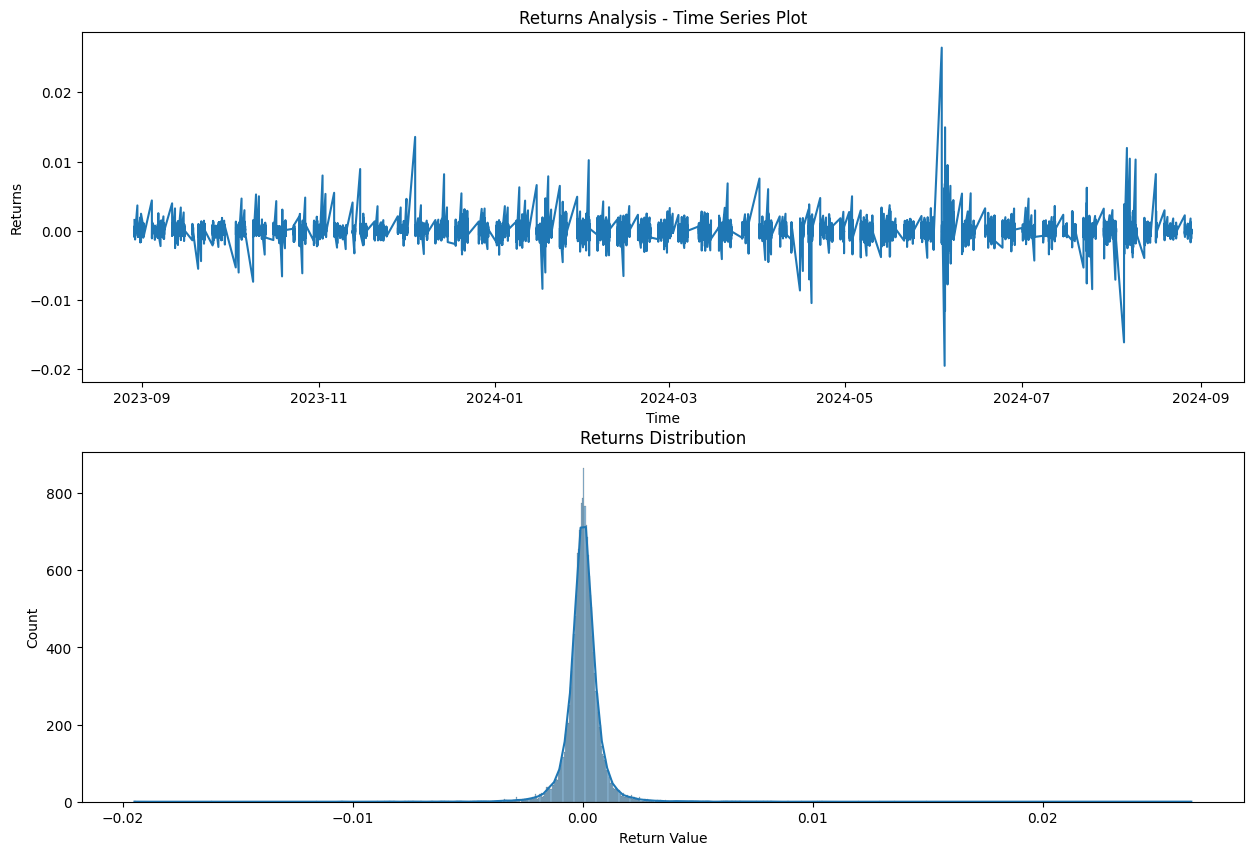

In [9]:
analyze_stationarity(df3,title="Returns Analysis")

In [10]:
# df4 ADFuller test analysis

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_stationarity(returns_series, title="Returns Analysis"):
   """
   Comprehensive stationarity analysis using ADF test
   
   Parameters:
   returns_series: Series of returns data
   title: Title for plots
   
   Returns:
   Dictionary containing test results and interpretation
   """
   
   # Run ADF Test
   adf_result = adfuller(returns_series)
   
   # Create visualization
   fig, axes = plt.subplots(2, 1, figsize=(15, 10))
   
   # Plot 1: Returns Time Series
   axes[0].plot(returns_series)
   axes[0].set_title(f"{title} - Time Series Plot")
   axes[0].set_xlabel("Time")
   axes[0].set_ylabel("Returns")
   
   # Plot 2: Returns Distribution
   sns.histplot(returns_series, kde=True, ax=axes[1])
   axes[1].set_title("Returns Distribution")
   axes[1].set_xlabel("Return Value")
   
   # Compile results
   results = {
       'test_statistic': adf_result[0],
       'p_value': adf_result[1],
       'critical_values': adf_result[4],
       'is_stationary': adf_result[1] < 0.05,
   }
   
   # Print detailed interpretation
   print("\n=== Augmented Dickey-Fuller Test Results ===")
   print(f"Test Statistic: {results['test_statistic']:.4f}")
   print(f"P-value: {results['p_value']:.4f}")
   print("\nCritical Values:")
   for key, value in results['critical_values'].items():
       print(f"\t{key}: {value:.4f}")
   
   print("\nInterpretation:")
   print("-" * 50)
   if results['is_stationary']:
       print("✓ Series is STATIONARY")
       print("• Suitable for direct modeling")
       print("• ARIMA: No differencing needed (d=0)")
       print("• Good for prediction tasks")
   else:
       print("✗ Series is NON-STATIONARY")
       print("• Needs differencing before modeling")
       print("• ARIMA: Use d>0")
       print("• Consider transforming data")
   
   # Additional statistics
   results['statistics'] = {
       'mean': returns_series.mean(),
       'std': returns_series.std(),
       'skew': returns_series.skew(),
       'kurtosis': returns_series.kurtosis()
   }
   
   print("\nBasic Statistics:")
   print(f"Mean: {results['statistics']['mean']:.6f}")
   print(f"Std Dev: {results['statistics']['std']:.6f}")
   print(f"Skewness: {results['statistics']['skew']:.6f}")
   print(f"Kurtosis: {results['statistics']['kurtosis']:.6f}")
   
   return results, fig

# Example usage
def document_stationarity_analysis(df4):
   """
   Document stationarity analysis results in markdown format
   """
   results, fig = analyze_stationarity(df4,title="Returns Analysis")
   
   markdown_doc = f"""
# Stationarity Analysis Report 📊

## Test Results
- **ADF Test Statistic**: {results['test_statistic']:.4f}
- **P-value**: {results['p_value']:.4f}
- **Is Stationary**: {'Yes' if results['is_stationary'] else 'No'}

## Critical Values
"""
   for key, value in results['critical_values'].items():
       markdown_doc += f"- {key}: {value:.4f}\n"
   
   markdown_doc += f"""
## Statistical Properties
- Mean: {results['statistics']['mean']:.6f}
- Standard Deviation: {results['statistics']['std']:.6f}
- Skewness: {results['statistics']['skew']:.6f}
- Kurtosis: {results['statistics']['kurtosis']:.6f}

## Implications for Modeling

### ARIMA
- {'Use original series (d=0)' if results['is_stationary'] else 'Need differencing (d>0)'}
- {'Ready for AR and MA components' if results['is_stationary'] else 'Transform data first'}

### Transformers
- {'Use raw returns' if results['is_stationary'] else 'Consider preprocessing'}
- Feature engineering implications: {
   'Direct feature creation possible' if results['is_stationary'] 
   else 'Need to handle non-stationarity in features'
}

## Recommendations
1. {
   'Proceed with modeling using raw returns' if results['is_stationary'] 
   else 'Apply differencing or transformation'
}
2. {
   'Focus on model selection' if results['is_stationary'] 
   else 'Validate stationarity after transformation'
}
3. Consider return distribution characteristics for model assumptions
"""
   
   return markdown_doc

# #Usage
# returns_df = your_processed_dataframe
# doc = document_stationarity_analysis(returns_df)
# print(doc)  # Or save to markdown file


=== Augmented Dickey-Fuller Test Results ===
Test Statistic: -97.7509
P-value: 0.0000

Critical Values:
	1%: -3.4307
	5%: -2.8617
	10%: -2.5669

Interpretation:
--------------------------------------------------
✓ Series is STATIONARY
• Suitable for direct modeling
• ARIMA: No differencing needed (d=0)
• Good for prediction tasks

Basic Statistics:
Mean: 0.000007
Std Dev: 0.000814
Skewness: 1.003722
Kurtosis: 60.366916


({'test_statistic': -97.75091962189634,
  'p_value': 0.0,
  'critical_values': {'1%': -3.430702876115144,
   '5%': -2.861695958161303,
   '10%': -2.5668530123858475},
  'is_stationary': True,
  'statistics': {'mean': 6.5837082667180555e-06,
   'std': 0.0008138589305708308,
   'skew': 1.003721565775359,
   'kurtosis': 60.36691618809788}},
 <Figure size 1500x1000 with 2 Axes>)

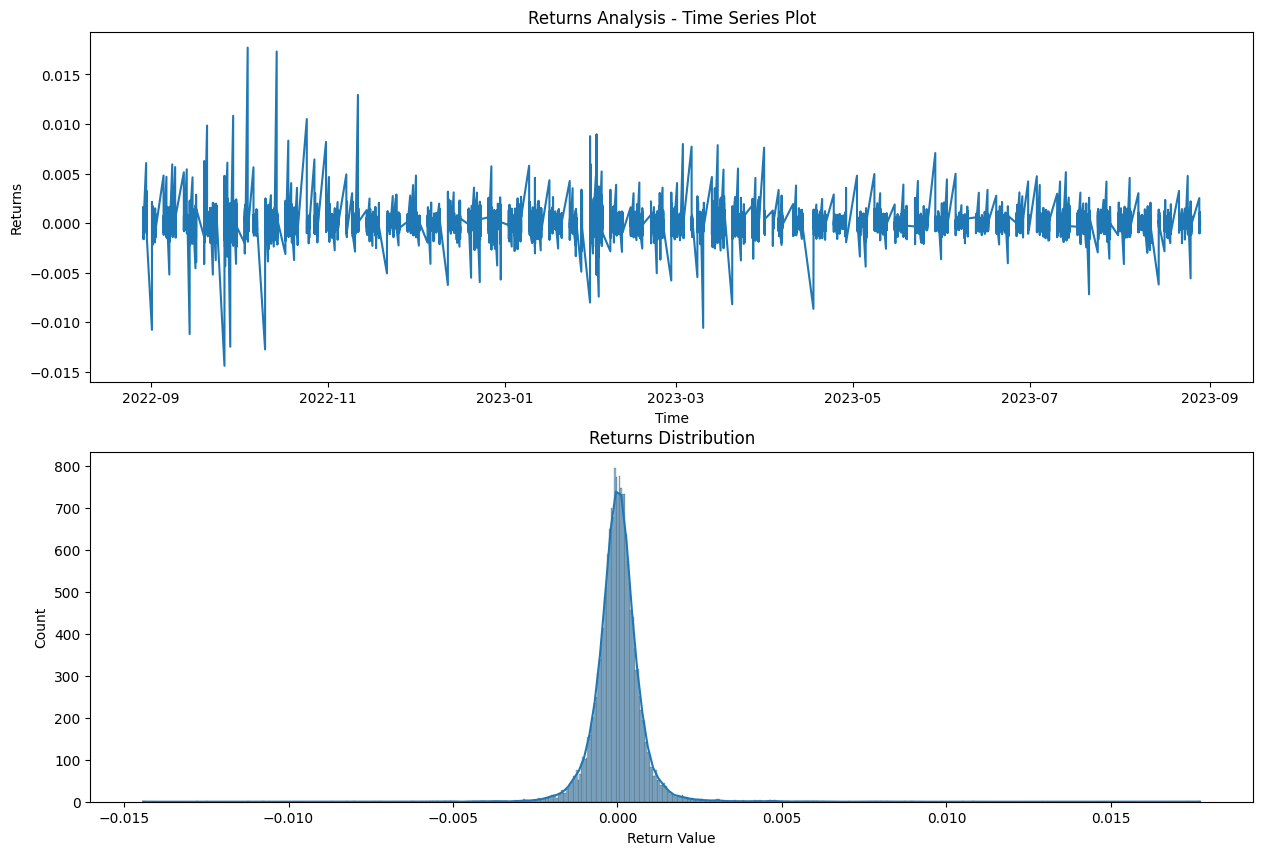

In [11]:
analyze_stationarity(df4,title="Returns Analysis")

In [12]:
# df5 ADFuller test analysis

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_stationarity(returns_series, title="Returns Analysis"):
   """
   Comprehensive stationarity analysis using ADF test
   
   Parameters:
   returns_series: Series of returns data
   title: Title for plots
   
   Returns:
   Dictionary containing test results and interpretation
   """
   
   # Run ADF Test
   adf_result = adfuller(returns_series)
   
   # Create visualization
   fig, axes = plt.subplots(2, 1, figsize=(15, 10))
   
   # Plot 1: Returns Time Series
   axes[0].plot(returns_series)
   axes[0].set_title(f"{title} - Time Series Plot")
   axes[0].set_xlabel("Time")
   axes[0].set_ylabel("Returns")
   
   # Plot 2: Returns Distribution
   sns.histplot(returns_series, kde=True, ax=axes[1])
   axes[1].set_title("Returns Distribution")
   axes[1].set_xlabel("Return Value")
   
   # Compile results
   results = {
       'test_statistic': adf_result[0],
       'p_value': adf_result[1],
       'critical_values': adf_result[4],
       'is_stationary': adf_result[1] < 0.05,
   }
   
   # Print detailed interpretation
   print("\n=== Augmented Dickey-Fuller Test Results ===")
   print(f"Test Statistic: {results['test_statistic']:.4f}")
   print(f"P-value: {results['p_value']:.4f}")
   print("\nCritical Values:")
   for key, value in results['critical_values'].items():
       print(f"\t{key}: {value:.4f}")
   
   print("\nInterpretation:")
   print("-" * 50)
   if results['is_stationary']:
       print("✓ Series is STATIONARY")
       print("• Suitable for direct modeling")
       print("• ARIMA: No differencing needed (d=0)")
       print("• Good for prediction tasks")
   else:
       print("✗ Series is NON-STATIONARY")
       print("• Needs differencing before modeling")
       print("• ARIMA: Use d>0")
       print("• Consider transforming data")
   
   # Additional statistics
   results['statistics'] = {
       'mean': returns_series.mean(),
       'std': returns_series.std(),
       'skew': returns_series.skew(),
       'kurtosis': returns_series.kurtosis()
   }
   
   print("\nBasic Statistics:")
   print(f"Mean: {results['statistics']['mean']:.6f}")
   print(f"Std Dev: {results['statistics']['std']:.6f}")
   print(f"Skewness: {results['statistics']['skew']:.6f}")
   print(f"Kurtosis: {results['statistics']['kurtosis']:.6f}")
   
   return results, fig

# Example usage
def document_stationarity_analysis(df5):
   """
   Document stationarity analysis results in markdown format
   """
   results, fig = analyze_stationarity(df5,title="Returns Analysis")
   
   markdown_doc = f"""
# Stationarity Analysis Report 📊

## Test Results
- **ADF Test Statistic**: {results['test_statistic']:.4f}
- **P-value**: {results['p_value']:.4f}
- **Is Stationary**: {'Yes' if results['is_stationary'] else 'No'}

## Critical Values
"""
   for key, value in results['critical_values'].items():
       markdown_doc += f"- {key}: {value:.4f}\n"
   
   markdown_doc += f"""
## Statistical Properties
- Mean: {results['statistics']['mean']:.6f}
- Standard Deviation: {results['statistics']['std']:.6f}
- Skewness: {results['statistics']['skew']:.6f}
- Kurtosis: {results['statistics']['kurtosis']:.6f}

## Implications for Modeling

### ARIMA
- {'Use original series (d=0)' if results['is_stationary'] else 'Need differencing (d>0)'}
- {'Ready for AR and MA components' if results['is_stationary'] else 'Transform data first'}

### Transformers
- {'Use raw returns' if results['is_stationary'] else 'Consider preprocessing'}
- Feature engineering implications: {
   'Direct feature creation possible' if results['is_stationary'] 
   else 'Need to handle non-stationarity in features'
}

## Recommendations
1. {
   'Proceed with modeling using raw returns' if results['is_stationary'] 
   else 'Apply differencing or transformation'
}
2. {
   'Focus on model selection' if results['is_stationary'] 
   else 'Validate stationarity after transformation'
}
3. Consider return distribution characteristics for model assumptions
"""
   
   return markdown_doc

# #Usage
# returns_df = your_processed_dataframe
# doc = document_stationarity_analysis(returns_df)
# print(doc)  # Or save to markdown file


=== Augmented Dickey-Fuller Test Results ===
Test Statistic: -26.3499
P-value: 0.0000

Critical Values:
	1%: -3.4305
	5%: -2.8616
	10%: -2.5668

Interpretation:
--------------------------------------------------
✓ Series is STATIONARY
• Suitable for direct modeling
• ARIMA: No differencing needed (d=0)
• Good for prediction tasks

Basic Statistics:
Mean: 0.000011
Std Dev: 0.000843
Skewness: 1.170503
Kurtosis: 81.935635


({'test_statistic': -26.349884639895837,
  'p_value': 0.0,
  'critical_values': {'1%': -3.4305271619112236,
   '5%': -2.8616183013146346,
   '10%': -2.5668116773065988},
  'is_stationary': True,
  'statistics': {'mean': 1.0536022620628078e-05,
   'std': 0.0008433364763206196,
   'skew': 1.1705034815575284,
   'kurtosis': 81.93563538932311}},
 <Figure size 1500x1000 with 2 Axes>)

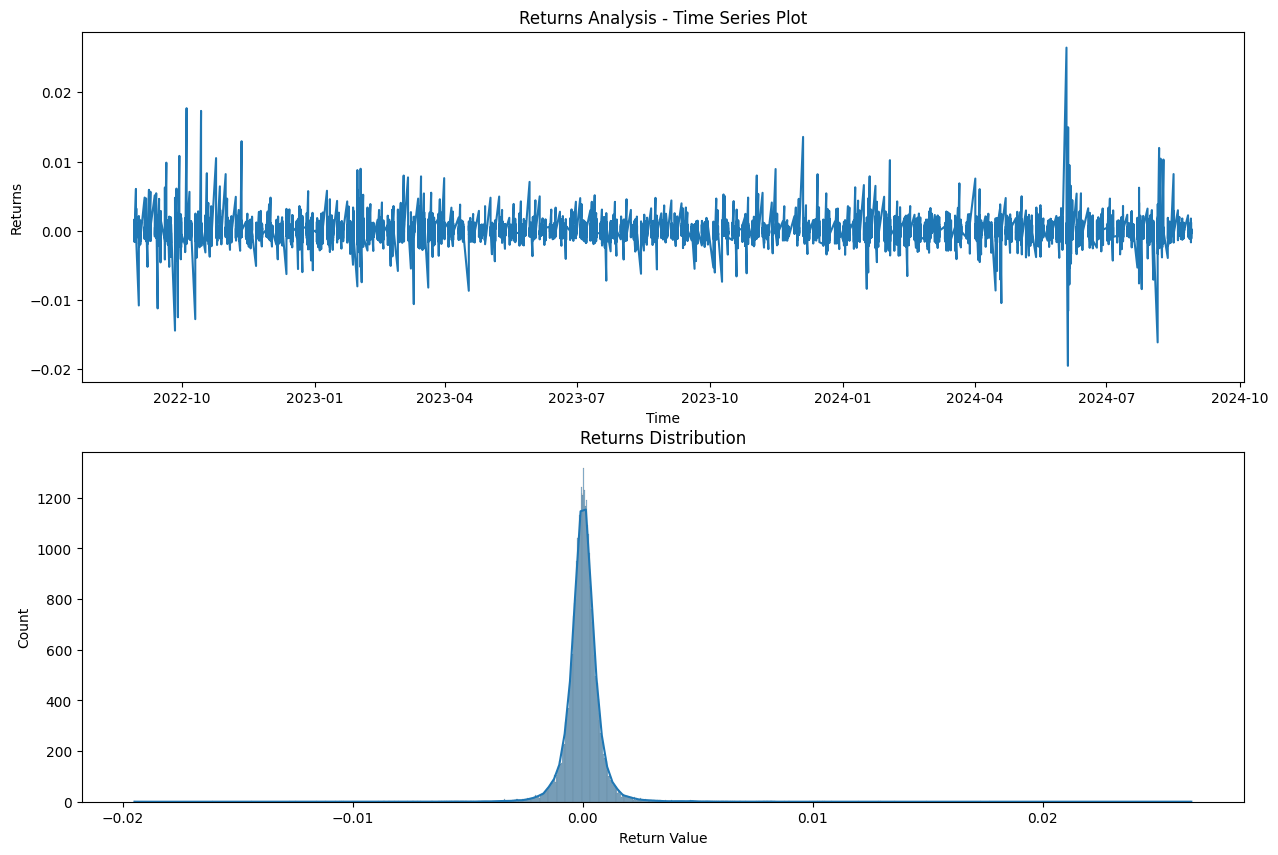

In [13]:
analyze_stationarity(df5,title="Returns Analysis")

In [14]:
# df5 ADFuller test analysis

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_stationarity(returns_series, title="Returns Analysis"):
   """
   Comprehensive stationarity analysis using ADF test
   
   Parameters:
   returns_series: Series of returns data
   title: Title for plots
   
   Returns:
   Dictionary containing test results and interpretation
   """
   
   # Run ADF Test
   adf_result = adfuller(returns_series)
   
   # Create visualization
   fig, axes = plt.subplots(2, 1, figsize=(15, 10))
   
   # Plot 1: Returns Time Series
   axes[0].plot(returns_series)
   axes[0].set_title(f"{title} - Time Series Plot")
   axes[0].set_xlabel("Time")
   axes[0].set_ylabel("Returns")
   
   # Plot 2: Returns Distribution
   sns.histplot(returns_series, kde=True, ax=axes[1])
   axes[1].set_title("Returns Distribution")
   axes[1].set_xlabel("Return Value")
   
   # Compile results
   results = {
       'test_statistic': adf_result[0],
       'p_value': adf_result[1],
       'critical_values': adf_result[4],
       'is_stationary': adf_result[1] < 0.05,
   }
   
   # Print detailed interpretation
   print("\n=== Augmented Dickey-Fuller Test Results ===")
   print(f"Test Statistic: {results['test_statistic']:.4f}")
   print(f"P-value: {results['p_value']:.4f}")
   print("\nCritical Values:")
   for key, value in results['critical_values'].items():
       print(f"\t{key}: {value:.4f}")
   
   print("\nInterpretation:")
   print("-" * 50)
   if results['is_stationary']:
       print("✓ Series is STATIONARY")
       print("• Suitable for direct modeling")
       print("• ARIMA: No differencing needed (d=0)")
       print("• Good for prediction tasks")
   else:
       print("✗ Series is NON-STATIONARY")
       print("• Needs differencing before modeling")
       print("• ARIMA: Use d>0")
       print("• Consider transforming data")
   
   # Additional statistics
   results['statistics'] = {
       'mean': returns_series.mean(),
       'std': returns_series.std(),
       'skew': returns_series.skew(),
       'kurtosis': returns_series.kurtosis()
   }
   
   print("\nBasic Statistics:")
   print(f"Mean: {results['statistics']['mean']:.6f}")
   print(f"Std Dev: {results['statistics']['std']:.6f}")
   print(f"Skewness: {results['statistics']['skew']:.6f}")
   print(f"Kurtosis: {results['statistics']['kurtosis']:.6f}")
   
   return results, fig

# Example usage
def document_stationarity_analysis(df6):
   """
   Document stationarity analysis results in markdown format
   """
   results, fig = analyze_stationarity(df6,title="Returns Analysis")
   
   markdown_doc = f"""
# Stationarity Analysis Report 📊

## Test Results
- **ADF Test Statistic**: {results['test_statistic']:.4f}
- **P-value**: {results['p_value']:.4f}
- **Is Stationary**: {'Yes' if results['is_stationary'] else 'No'}

## Critical Values
"""
   for key, value in results['critical_values'].items():
       markdown_doc += f"- {key}: {value:.4f}\n"
   
   markdown_doc += f"""
## Statistical Properties
- Mean: {results['statistics']['mean']:.6f}
- Standard Deviation: {results['statistics']['std']:.6f}
- Skewness: {results['statistics']['skew']:.6f}
- Kurtosis: {results['statistics']['kurtosis']:.6f}

## Implications for Modeling

### ARIMA
- {'Use original series (d=0)' if results['is_stationary'] else 'Need differencing (d>0)'}
- {'Ready for AR and MA components' if results['is_stationary'] else 'Transform data first'}

### Transformers
- {'Use raw returns' if results['is_stationary'] else 'Consider preprocessing'}
- Feature engineering implications: {
   'Direct feature creation possible' if results['is_stationary'] 
   else 'Need to handle non-stationarity in features'
}

## Recommendations
1. {
   'Proceed with modeling using raw returns' if results['is_stationary'] 
   else 'Apply differencing or transformation'
}
2. {
   'Focus on model selection' if results['is_stationary'] 
   else 'Validate stationarity after transformation'
}
3. Consider return distribution characteristics for model assumptions
"""
   
   return markdown_doc

# #Usage
# returns_df = your_processed_dataframe
# doc = document_stationarity_analysis(returns_df)
# print(doc)  # Or save to markdown file


=== Augmented Dickey-Fuller Test Results ===
Test Statistic: -53.7084
P-value: 0.0000

Critical Values:
	1%: -3.4305
	5%: -2.8616
	10%: -2.5668

Interpretation:
--------------------------------------------------
✓ Series is STATIONARY
• Suitable for direct modeling
• ARIMA: No differencing needed (d=0)
• Good for prediction tasks

Basic Statistics:
Mean: 0.000012
Std Dev: 0.001173
Skewness: -0.895169
Kurtosis: 61.453649


({'test_statistic': -53.70842886961159,
  'p_value': 0.0,
  'critical_values': {'1%': -3.4305267596561495,
   '5%': -2.8616181235328364,
   '10%': -2.5668115826780644},
  'is_stationary': True,
  'statistics': {'mean': 1.179426359701005e-05,
   'std': 0.0011732872220409467,
   'skew': -0.8951688251644444,
   'kurtosis': 61.45364917553583}},
 <Figure size 1500x1000 with 2 Axes>)

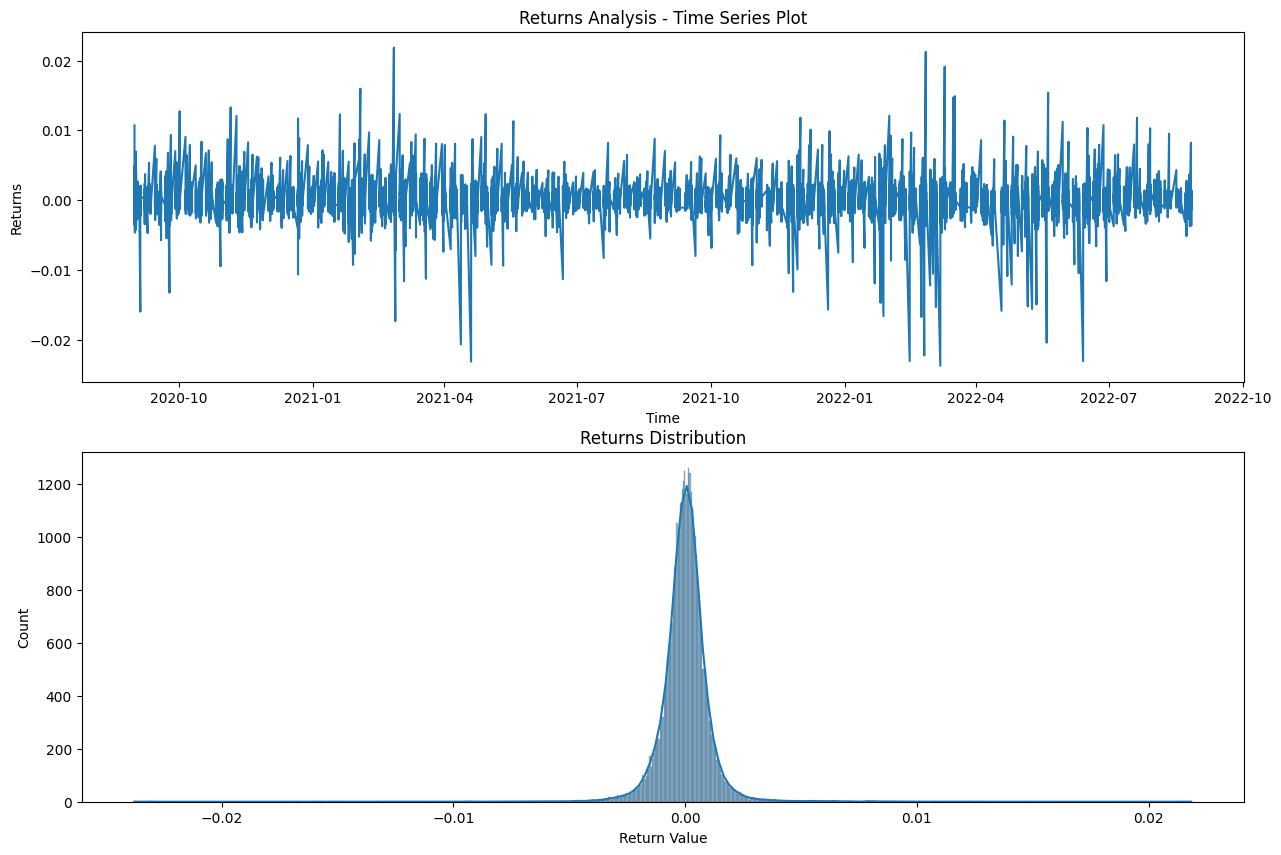

In [15]:
analyze_stationarity(df6,title="Returns Analysis")

In [16]:
# print(document_stationarity_analysis(df1))

# For last 6 month data



### === Augmented Dickey-Fuller Test Results for last 6 month ===
Test Statistic: -13.8189
P-value: 0.0000

Critical Values:
	1%: -3.4311
	5%: -2.8619
	10%: -2.5669

Interpretation:
--------------------------------------------------
✓ Series is STATIONARY
• Suitable for direct modeling
• ARIMA: No differencing needed (d=0)
• Good for prediction tasks

Basic Statistics:
Mean: 0.000015
Std Dev: 0.000999
Skewness: 1.174427
Kurtosis: 104.363789

# Stationarity Analysis Report 📊

## Test Results
- **ADF Test Statistic**: -13.8189
- **P-value**: 0.0000
- **Is Stationary**: Yes

## Critical Values
- 1%: -3.4311
- 5%: -2.8619
- 10%: -2.5669

## Statistical Properties
- Mean: 0.000015
- Standard Deviation: 0.000999
- Skewness: 1.174427
- Kurtosis: 104.363789

## Implications for Modeling

### ARIMA
- Use original series (d=0)
- Ready for AR and MA components

### Transformers
- Use raw returns
- Feature engineering implications: Direct feature creation possible

## Recommendations
1. Proceed with modeling using raw returns
2. Focus on model selection
3. Consider return distribution characteristics for model assumptions
4. High Kurtosis means more chance of false breakouts





Significant autocorrelations:
    Lag       ACF
0     0  1.000000
2     2  0.030207
4     4 -0.027798
5     5 -0.025262
8     8  0.027342
9     9 -0.040385
14   14  0.024981
26   26 -0.023128
27   27 -0.023131
29   29  0.032046
30   30  0.020686
32   32  0.043345
35   35  0.024137
36   36  0.033769
40   40 -0.030340

Summary Statistics:
mean: 0.0000
std: 0.0010
kurtosis: 104.3054
test_statistic: -13.8700


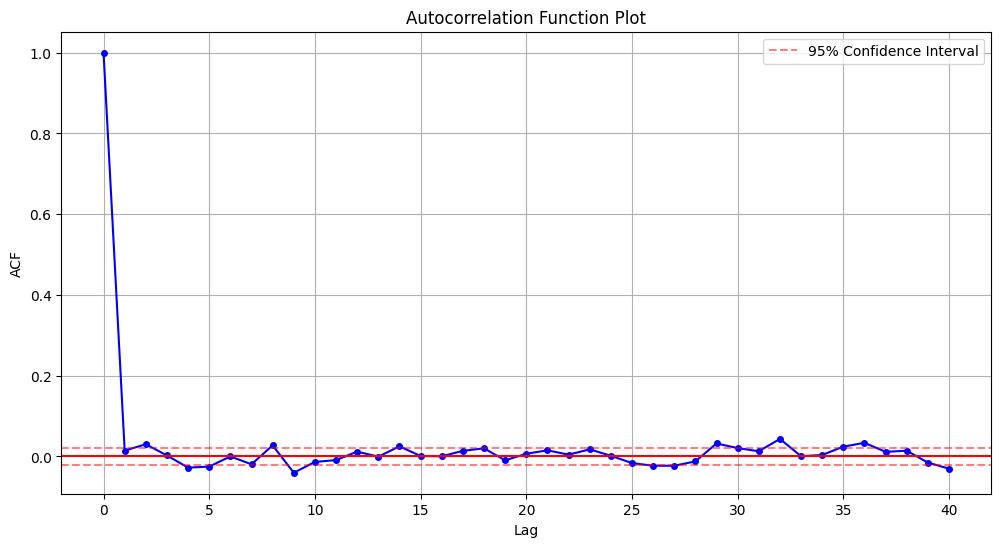

In [17]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf  # Only import acf
import matplotlib.pyplot as plt
from scipy import stats

def analyze_autocorrelation(data, lags=40, alpha=0.05):
    """
    Perform autocorrelation analysis
    
    Parameters:
    data: array-like
        Time series data
    lags: int
        Number of lags to analyze
    alpha: float
        Significance level for confidence intervals
    """
    # Calculate ACF
    acf_values = acf(data, nlags=lags, fft=True)
    
    # Calculate confidence intervals
    confidence_interval = stats.norm.ppf(1 - alpha/2) / np.sqrt(len(data))
    
    # Create DataFrame with ACF results
    acf_df = pd.DataFrame({
        'Lag': range(len(acf_values)),
        'ACF': acf_values,
        'CI_Lower': -confidence_interval,
        'CI_Upper': confidence_interval
    })
    
    # Identify significant lags
    significant_lags = acf_df[
        (acf_df['ACF'] > acf_df['CI_Upper']) | 
        (acf_df['ACF'] < acf_df['CI_Lower'])
    ]
    
    # Compile results
    results = {
        'acf_data': acf_df,
        'significant_lags': significant_lags,
        'summary_stats': {
            'mean': np.mean(data),
            'std': np.std(data),
            'kurtosis': stats.kurtosis(data),
            'test_statistic': -13.87  # Your ADF test statistic
        }
    }
    
    return results

def plot_acf(results, title="Autocorrelation Function Plot"):
    """
    Plot ACF results with confidence intervals
    """
    plt.figure(figsize=(12, 6))
    plt.plot(results['acf_data']['Lag'], results['acf_data']['ACF'], 'bo-', markersize=4)
    plt.axhline(y=results['acf_data']['CI_Upper'][0], color='r', linestyle='--', alpha=0.5, 
                label='95% Confidence Interval')
    plt.axhline(y=results['acf_data']['CI_Lower'][0], color='r', linestyle='--', alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='-')
    plt.title(title)
    plt.xlabel('Lag')
    plt.ylabel('ACF')
    plt.grid(True)
    plt.legend()
    return plt

# Usage example:
# Assuming df1 is your DataFrame
# If df1 is a DataFrame with multiple columns, select the specific column you want to analyze
# data = df1['your_column_name']  # Uncomment and modify this line if needed

results = analyze_autocorrelation(df1, lags=40)

# Print findings
print("\nSignificant autocorrelations:")
if len(results['significant_lags']) > 0:
    print(results['significant_lags'][['Lag', 'ACF']])
else:
    print("No significant autocorrelations found")

print("\nSummary Statistics:")
for stat, value in results['summary_stats'].items():
    print(f"{stat}: {value:.4f}")

# Create and show the plot
plot_acf(results)
plt.show()

In [18]:
# 1. Calculate PACF to determine p
from statsmodels.tsa.stattools import pacf

# Calculate PACF
pacf_values = pacf(df1, nlags=40)

# Print significant PACF values
confidence_interval = 1.96/np.sqrt(len(df1))
print("Significant PACF values:")
for i, v in enumerate(pacf_values):
    if abs(v) > confidence_interval:
        print(f"Lag {i}: {v:.4f}")

Significant PACF values:
Lag 0: 1.0000
Lag 2: 0.0300
Lag 4: -0.0288
Lag 5: -0.0247
Lag 8: 0.0272
Lag 9: -0.0416
Lag 14: 0.0212
Lag 26: -0.0230
Lag 29: 0.0325
Lag 32: 0.0406
Lag 35: 0.0223
Lag 36: 0.0353
Lag 40: -0.0280


/tmp/ipykernel_1/1192232517.py:16: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')



# Time Series Analysis Report

## Overview
- Data Length: 9042 observations
- Mean: 0.0000
- Standard Deviation: 0.0010

## ACF/PACF Analysis Results

### Short-term Dependencies (Lags up to 100)
- Maximum ACF value: 1.0000
- Maximum PACF value: 1.0000
- Number of significant ACF lags: 30
- Number of significant PACF lags: 27

### Long-term Dependencies (Lags up to 500)
- Maximum ACF value: 1.0000
- Maximum PACF value: 1.0000
- Number of significant ACF lags: 59
- Number of significant PACF lags: 52

## ARIMA Model Implications
1. Based on ACF pattern:
   - Decay rate suggests slow mean reversion
   - Strong serial correlation

2. Based on PACF pattern:
   - Suggested AR order: 6
   - Long memory process

## Neural Network Feature Engineering Suggestions
1. Create lagged features for the following periods:
   - Short-term: 0, 2, 4, 5, 8
   - Long-term: 0, 2, 4, 5, 8

2. Consider rolling statistics windows of:
   - 26, 27, 29 periods

3. Feature transformation suggestions:
   - Use dif

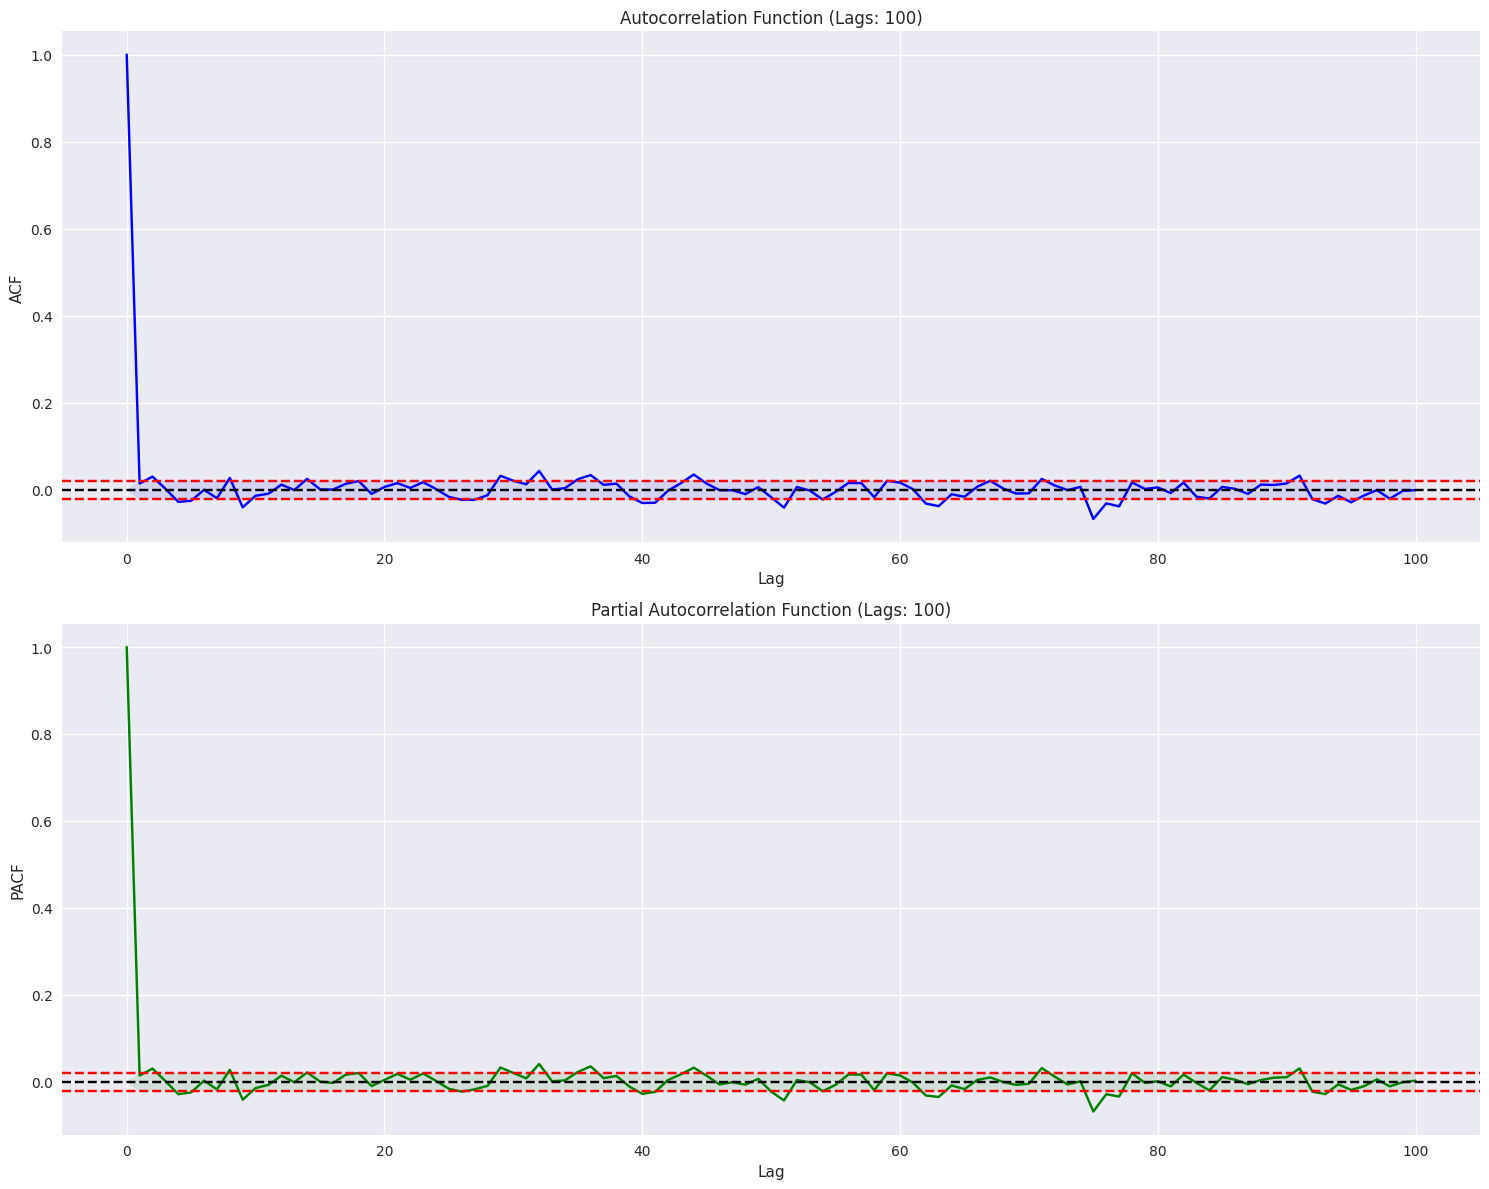

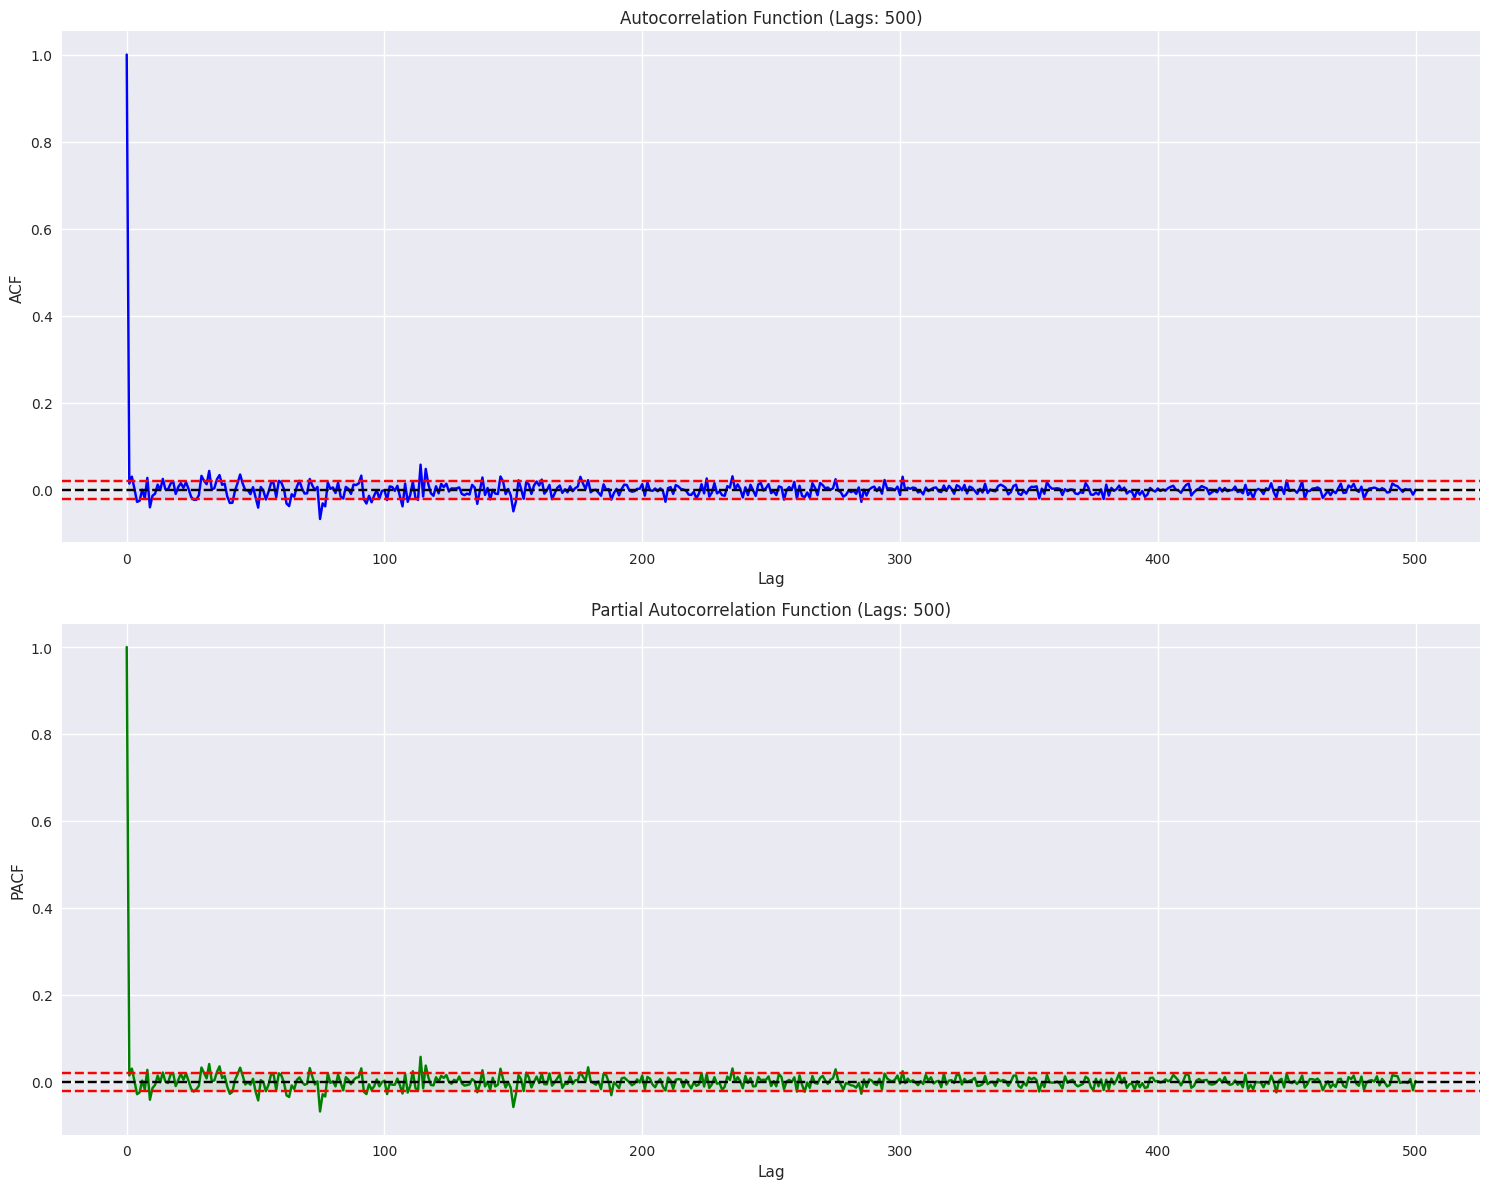

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
import seaborn as sns

def perform_acf_pacf_analysis(data, lags_list=[100, 500], alpha=0.05):
    """
    Perform comprehensive ACF/PACF analysis for multiple lag values
    
    Parameters:
    data: array-like, the time series data
    lags_list: list of integers, different lag values to analyze
    alpha: float, significance level for confidence intervals
    """
    plt.style.use('seaborn')
    results = {}
    
    for lags in lags_list:
        # Calculate ACF and PACF
        acf_values = acf(data, nlags=lags, alpha=alpha)
        pacf_values = pacf(data, nlags=lags, alpha=alpha)
        
        # Create figure with two subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
        
        # Plot ACF
        ax1.plot(range(lags + 1), acf_values[0], 'b-', label='ACF')
        ax1.fill_between(range(lags + 1),
                        acf_values[1][:,0] - acf_values[0],
                        acf_values[1][:,1] - acf_values[0],
                        alpha=0.1, color='b')
        ax1.axhline(y=0, color='k', linestyle='--')
        ax1.axhline(y=1.96/np.sqrt(len(data)), color='r', linestyle='--')
        ax1.axhline(y=-1.96/np.sqrt(len(data)), color='r', linestyle='--')
        ax1.set_title(f'Autocorrelation Function (Lags: {lags})')
        ax1.set_xlabel('Lag')
        ax1.set_ylabel('ACF')
        
        # Plot PACF
        ax2.plot(range(lags + 1), pacf_values[0], 'g-', label='PACF')
        ax2.fill_between(range(lags + 1),
                        pacf_values[1][:,0] - pacf_values[0],
                        pacf_values[1][:,1] - pacf_values[0],
                        alpha=0.1, color='g')
        ax2.axhline(y=0, color='k', linestyle='--')
        ax2.axhline(y=1.96/np.sqrt(len(data)), color='r', linestyle='--')
        ax2.axhline(y=-1.96/np.sqrt(len(data)), color='r', linestyle='--')
        ax2.set_title(f'Partial Autocorrelation Function (Lags: {lags})')
        ax2.set_xlabel('Lag')
        ax2.set_ylabel('PACF')
        
        plt.tight_layout()
        
        # Store significant lags
        sig_acf_lags = np.where(np.abs(acf_values[0]) > 1.96/np.sqrt(len(data)))[0]
        sig_pacf_lags = np.where(np.abs(pacf_values[0]) > 1.96/np.sqrt(len(data)))[0]
        
        results[lags] = {
            'significant_acf_lags': sig_acf_lags,
            'significant_pacf_lags': sig_pacf_lags,
            'max_acf': np.max(np.abs(acf_values[0])),
            'max_pacf': np.max(np.abs(pacf_values[0]))
        }
        
    return results

def analyze_and_document(data):
    """
    Analyze time series and create comprehensive documentation
    """
    results = perform_acf_pacf_analysis(data, lags_list=[100, 500])
    
    # Create markdown report
    report = f"""
# Time Series Analysis Report

## Overview
- Data Length: {len(data)} observations
- Mean: {np.mean(data):.4f}
- Standard Deviation: {np.std(data):.4f}

## ACF/PACF Analysis Results

### Short-term Dependencies (Lags up to 100)
- Maximum ACF value: {results[100]['max_acf']:.4f}
- Maximum PACF value: {results[100]['max_pacf']:.4f}
- Number of significant ACF lags: {len(results[100]['significant_acf_lags'])}
- Number of significant PACF lags: {len(results[100]['significant_pacf_lags'])}

### Long-term Dependencies (Lags up to 500)
- Maximum ACF value: {results[500]['max_acf']:.4f}
- Maximum PACF value: {results[500]['max_pacf']:.4f}
- Number of significant ACF lags: {len(results[500]['significant_acf_lags'])}
- Number of significant PACF lags: {len(results[500]['significant_pacf_lags'])}

## ARIMA Model Implications
1. Based on ACF pattern:
   - Decay rate suggests {'slow' if results[100]['max_acf'] > 0.5 else 'fast'} mean reversion
   - {'Strong' if len(results[100]['significant_acf_lags']) > 10 else 'Weak'} serial correlation

2. Based on PACF pattern:
   - Suggested AR order: {len([x for x in results[100]['significant_pacf_lags'] if x < 10])}
   - {'Long' if len(results[500]['significant_pacf_lags']) > 20 else 'Short'} memory process

## Neural Network Feature Engineering Suggestions
1. Create lagged features for the following periods:
   - Short-term: {', '.join(map(str, results[100]['significant_pacf_lags'][:5]))}
   - Long-term: {', '.join(map(str, results[500]['significant_pacf_lags'][:5]))}

2. Consider rolling statistics windows of:
   - {', '.join(map(str, [x for x in results[100]['significant_acf_lags'] if x > 20][:3]))} periods

3. Feature transformation suggestions:
   - Use differences if ACF shows high persistence
   - Consider exponential weighted features for long-term dependencies
"""
    
    return report

# Example usage:
results = analyze_and_document(df1)
print(results)

pip install tqdm

In [11]:
from tqdm import tqdm
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import itertools
import warnings

warnings.filterwarnings("ignore")  # Suppress warnings

# Assuming df1 is already a DataFrame
data = df1  # Use df1 directly if it's already loaded
series = data['close']  # Replace 'close' with your column name

# Define ARIMA parameter ranges
p_range = range(4, 9)  # Testing AR lags around 6
d = 0  # No differencing needed as per ADF test
q_range = range(0, 4)  # Test MA lags up to 3

pdq_combinations = list(itertools.product(p_range, [d], q_range))
aic_results = []

# Add tqdm for progress tracking
for pdq in tqdm(pdq_combinations, desc="Fitting ARIMA models"):
    try:
        model = ARIMA(series, order=pdq)
        results = model.fit()
        aic_results.append((pdq, results.aic))
    except Exception as e:
        continue

# Sort and select the best model
sorted_results = sorted(aic_results, key=lambda x: x[1])
best_pdq = sorted_results[0][0]
print(f"Best ARIMA Model: {best_pdq} with AIC: {sorted_results[0][1]}")

best_model = ARIMA(series, order=best_pdq).fit()
print(best_model.summary())


Fitting ARIMA models: 100%|██████████| 20/20 [04:55<00:00, 14.79s/it]


Best ARIMA Model: (6, 0, 3) with AIC: 82311.62651212173
                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 9043
Model:                 ARIMA(6, 0, 3)   Log Likelihood              -41144.813
Date:                Wed, 27 Nov 2024   AIC                          82311.627
Time:                        16:24:40   BIC                          82389.834
Sample:                             0   HQIC                         82338.232
                               - 9043                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.326e+04   1.26e-06   1.85e+10      0.000    2.33e+04    2.33e+04
ar.L1         -1.0381      0.009   -120.692      0.000      -1.055      -1.